In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from IPython.display import display, Markdown, Latex
import pandas as pd
from uncertainties import ufloat
from uncertainties import unumpy as unp
from scipy.optimize import curve_fit
from scipy import constants as const 
import math
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator

# PW11 Elektrische Schwingungen


## 1. Experiment

wichtige Formeln

Dämpfungskonstante $\delta$:
$$
\begin{equation}
\delta = \frac{R}{2L}
\end{equation}
$$

Eigenfrequenz $\omega_0$:
$$
\begin{equation}
\omega_0 = \sqrt{\frac{1}{LC}} \tag{2}
\end{equation}
$$

Kreisfrequenz $\omega$:
$$
\begin{equation}
\omega_d = \frac{2\pi}{T} \tag{3}
\end{equation}
$$

Amplitude A:
$$
\begin{equation}
A(t) = A_0 \cdot \exp^{-\delta t} \tag{4}
\end{equation}
$$ 

Linearer Zusammenhang Maxima A und Zeiten t:
$$
\ln(\frac{A_i}{A_0}) = -\delta t_i
$$

Eigenfrequenz $\omega_0$:
$$
\omega_0 = \sqrt{\omega_d^2 + \delta^2}
$$


Die Kreisfrequenz der Schwingung beträgt 32057.07 Rad pro Sekunde.
Die Schwingung hat einen Dämpfungskoeffizienten von 562+/-33 1/s. 


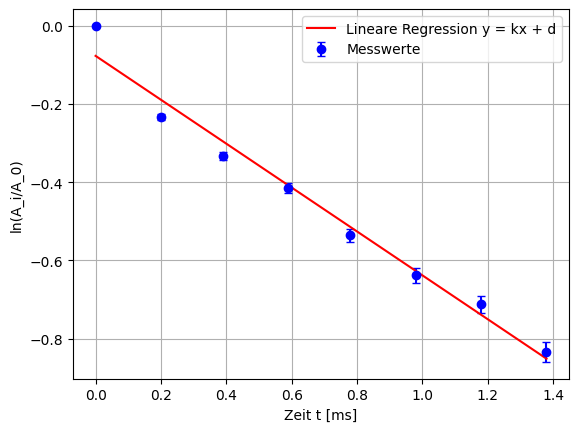

R^2 = 0.9793328741746073
Die Eigenfrequenz mit Berücksichtigung beträgt 32062.0+/-0.6 Rad pro Sekunde.
Der Kondensator besitzt die Kapazität C = (9.72790+/-0.00035)e-07 F und die Spule hat einen Widerstand von 1.12+/-0.07 Ohm.
R_g = (65.5+/-1.2) Omega
R = (64124.0+/-1.2) Omega


In [7]:
# Experiment 1

# 1.1
T1 = ((200+200+180+200+200+200+200+180+200+200)/10)*(10**(-6))
#T1 = 2*(10**(-4)) #periodendauer in s
omegad1 = (2*math.pi)/T1 #eigenfrequenz

#T2 = #periodendauer
#omegad2 = (2/math.pi)/T2

print(f"Die Kreisfrequenz der Schwingung beträgt {omegad1:.2f} Rad pro Sekunde.")

# 1.2
A0_1 = 10.6 # in V
A_t_1 = np.array([10.6, 8.4, 7.6, 7, 6.2, 5.6, 5.2, 4.6])
y_1 = np.log(A_t_1/A0_1)
t_1 = np.array([0, 200*10**(-6), 390*10**(-6), 590*10**(-6), 780*10**(-6), 980*10**(-6), 1180*10**(-6), 1380*10**(-6)]) # die wievielten maxima wir eintragen, achtung auf die reihenfolge!! in s
t_1_plot = t_1*10**3

#A0_2 = 
#A_t_2 = np.array([])
#y_2 = math.log(A_t_2/A0_2)
#t_2 = np.array([]) # die wievielten maxima wir eintragen, achtung auf die reihenfolge!!

res1 = linregress(t_1, y_1)
delta_1 = ufloat(res1.slope, res1.stderr)*(-1) # weil steigung -delta ist, wert also positiv
y_reg = res1.slope*t_1 + res1.intercept 

#res2 = linregress(t_2, y_2)
#delta_2 = ufloat(res2.slope, res2.stderr)*(-1) # vorzeichen geändert

print(f"Die Schwingung hat einen Dämpfungskoeffizienten von {delta_1} 1/s. ")

y_err = np.array(-y_1*0.03)

# plot
plt.figure()
#plt.scatter(t_1_plot, y_1, marker="o", label="Messwerte", color='blue')
plt.errorbar(t_1_plot, y_1, yerr=y_err, fmt="o", capsize=3, label="Messwerte", color="blue")
plt.plot(t_1_plot, y_reg, label="Lineare Regression y = kx + d", color="red")
plt.xlabel("Zeit t [ms]")
plt.ylabel("ln(A_i/A_0)")
plt.grid(True)
plt.legend()
plt.show()

r2 = res1.rvalue**2
print(f"R^2 = {r2}")


# 1.3
omega0_1 = unp.sqrt((omegad1)**2 + (delta_1)**2)
#omega0_2 = np.sqrt((omegad2)**2 + (delta_2)**2)

print(f"Die Eigenfrequenz mit Berücksichtigung beträgt {omega0_1} Rad pro Sekunde.")

# 1.4
L = 1*10**(-3) # Widerstand der Spule in Henri
#L = (RL)/2*delta_1 # achtung ob das eh weniger dämpfung ist
RL = L*(2*delta_1)
C = 1/((omega0_1)**2*L)

print(f"Der Kondensator besitzt die Kapazität C = {C} F und die Spule hat einen Widerstand von {RL} Ohm.")

# 1.5
#RD = 0.6 # veränderbarer Widerstand in Ohm
#R = RD + RL
#delta_3 = R/(2*L)
#diff = delta_3 - omega0_2

#print(f"Beim Dämpfungswiderstand {R} Ohm, mit RD = {RD}, tritt der Dämpfungskoeffizient {delta_3} auf, was der Eigenfrequenz \u03C9\u2080 mit einer Differenz von diff sehr nahe kommt.")

# 2a Fotos bei veränderung mit Dämpfung

# 2b aperiodischer Grenzfall (mit Stellwiderstand)
R_D_gemessen = ufloat(64.4, 64.4*0.015+0.2)               #[Ohm], empirisch ermitteln am Stellwiderstand (wie?)
R_gemessen = R_D_gemessen + RL         #[0hm], R_D + R_L

omega0 = unp.sqrt(1/(L*C)) 
R = 2 * L * omega0 *10**3                     #berechnet, aperiodischer Grenzfall: delta = omega0

print(f"R_g = ({R_gemessen}) Omega")
print(f"R = ({R}) Omega")


wertefreieschwingung1 = np.array([omega0_1, delta_1])
#wertefreieschwingung2 = np.array([omega0_2, delta_2])

## 2. Experiment
wichtige Formeln

Resonanzkurve $U_{C0}$ für kleine Dämpfungen gilt $\omega_{max} \approx \omega_0$:
$$
U_{C0} = U_0\frac{\omega_o^2}{\sqrt{(\omega_0^2 - \omega^2)^2 + 4\delta^2\omega^2}}
$$

Für den Abstand $\Delta \omega$ der Kreisfrequenzen:
$$
\Delta\omega = 2\delta
$$

Eigenfrequenz $\omega_0$: 
$$
\omega_0 = \sqrt{\omega_{max}^2 + 2\delta^2}
$$

Güte $Q$:
$$
Q \approx \frac{\omega_{max}}{\Delta\omega}
$$

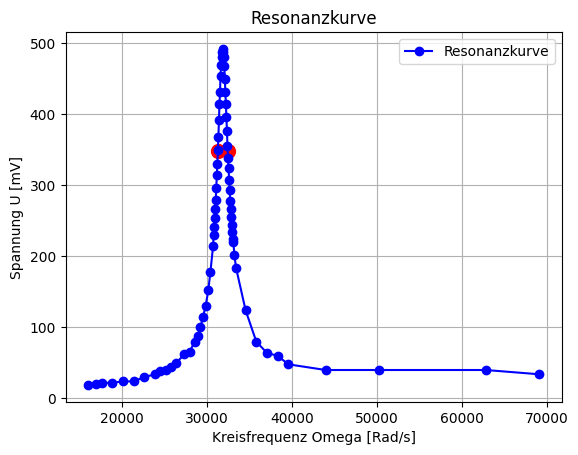

,Kreisfrequenz [Rad/s],Phasenverschiebung [Rad]
0,Omega_max,2.28
1,"0,8*Omega_max",3.01
2,"1,2*Omega_max",0.00


Die Eigenfrequenz dieser Schwingung liegt bei 31301.12 Rad pro Sekunde.
Die Dämfung beträgt hier 582.93.
Der Gütefaktor Q wurde als 26.84 bestimmt.


,Freie Schwingung,Erzwungene Schwingung
0,32062.0+/-0.6,31301.120939
1,562+/-33,582.934003


In [ ]:
# 2. experiment 

# 2.1
UC0 = np.array([19, 20, 22, 22, 24, 24, 30, 34, 38, 40, 44, 50, 62, 66, 80, 88, 100, 114, 130, 152, 178, 214, 230, 242, 254, 266, 280, 296, 314, 330, 350, 368, 392, 414, 432, 454, 470, 480, 488, 492, 488, 480, 468, 450, 432, 414, 396, 376, 356, 338, 324, 308, 294, 278, 266, 256, 244, 234, 225, 220, 202, 184, 124, 80, 64, 60, 48, 40, 40, 40, 34]) # punktweise messung der spannung in mV
f = np.array([2550, 2700, 2800, 3000, 3200, 3400, 3600, 3800, 3900, 4000, 4100, 4200, 4350, 4450, 4550, 4600, 4650, 4700, 4750, 4800, 4840, 4890, 4900, 4910, 4920, 4930, 4940, 4950, 4960, 4970, 4980, 4990, 5000, 5010, 5020, 5030, 5040, 5050, 5060, 5070, 5080, 5090, 5100, 5110, 5120, 5130, 5140, 5150, 5160, 5170, 5180, 5190, 5200, 5210, 5220, 5230, 5240, 5250, 5260, 5270, 5290, 5320, 5500, 5700, 5900, 6100, 6300, 7000, 8000, 10000, 11000]) # frequenz in Hz
omega = 2*math.pi*f
#f_max ist ca 4980 Hz

# 2.2
phi_omegamax = 2.28 #in rad
phi_0_8 = 3.01 
phi_1_2 = 0 #rad

phi = np.array([phi_omegamax, phi_0_8, phi_1_2])
name = np.array(["Omega_max", "0,8*Omega_max", "1,2*Omega_max"])

# eigenfrequenz, dämpfung, gütefaktor
Umax = 492 #mV
imax = np.argmax(UC0)
Uwurzel2 = (1/np.sqrt(2))*Umax
y1 = UC0[:imax+1]
omega1 = omega[:imax+1]
y2 = UC0[imax:]
omega2 = omega[imax:]
x1 = np.interp(Uwurzel2, y1, omega1)
x2 = np.interp(Uwurzel2, y2[::-1], omega2[::-1])
#omegamax = np.interp(Umax, UC0, omega)
omegamax = 4980*2*math.pi #gemessen
deltax = x2 - x1
delta_4 = deltax/2
Q = omegamax/deltax
omega0 = np.sqrt((omegamax)**2 + 2*((delta_4)**2))

werteerzwungeneschwingung = np.array([omega0, delta_4])

plt.figure()
plt.plot(omega, UC0, marker="o", label="Resonanzkurve", color='blue')
plt.scatter(x1, Uwurzel2, marker="o", color='red', s=100)
plt.scatter(x2, Uwurzel2, marker="o", color='red', s=100)
plt.xlabel("Kreisfrequenz Omega [Rad/s]")
plt.ylabel("Spannung U [mV]")
plt.title("Resonanzkurve")
plt.legend()
plt.grid(True)
plt.show()


tabelle = {
    "Kreisfrequenz [Rad/s]": name,
    "Phasenverschiebung [Rad]": phi
}
df = pd.DataFrame(tabelle)
display(df)

print(f"Die Eigenfrequenz dieser Schwingung liegt bei {omega0:.2f} Rad pro Sekunde.")
print(f"Die Dämfung beträgt hier {delta_4:.2f}.")
print(f"Der Gütefaktor Q wurde als {Q:.2f} bestimmt.")

vergleichstabelle = {
    "Freie Schwingung": wertefreieschwingung1,
    "Erzwungene Schwingung": werteerzwungeneschwingung
}
df_ = pd.DataFrame(vergleichstabelle)
display(df_)


## Diskussion

2. Experiment: 
Der Nulldurchgang der Spannung am Kondensator liegt zeitlich vor der Gesamtspannung, dementsprechend ist das Vorzeichen der Phasenverschiebung positiv.
Die Phasenverschiebung sollte bei der maximalen Frequenz etwa $\frac{\pi}{2}$ betragen, hier sind es etwa $\frac{3\pi}{4}$, was an einem Messfehler liegen könnte.